# ユーザー行動分析
### Google Analytics Sample
このノートブックでは**Google Analytics Sample**を用いて、ユーザーの行動を追ったポートフォリオになっています。分析の目的は、ユーザーが購入まで行くプロセスを確立させるために施策を考えることです。流入元分析やランディングページ分析などを行いながらユーザーの離脱しているポイントを可視化します。その結果をもとに施策提案をし、購入まで到達する顧客数を増やします。

### 分析内容
1. スキーマ構造とライブラリ・データの読み込み
2. 分析を始める前に
3. 流入元分析
4. デバイス分析
5. ブラウザ分析
6. ランディングページ分析
7. 前提条件の確認
8. 離脱ページ分析
9. 施策提案

## 1.スキーマ構造とライブラリ・データの読み込み
Bigqueryに保存されているGoogle Analytics Sampleのデータセットを分析内容に基づいてSQLを用いてcsvファイルを分割しました。その中でユーザーの行動を深く分析します。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sns.set()

df_source = pd.read_csv(r"C:\Users\gaku2\study\pandas\Google_Analytics\流入元データ.csv")
df_device = pd.read_csv(r"C:\Users\gaku2\study\pandas\Google_Analytics\流入元×デバイスデータ.csv")
df_browser = pd.read_csv(r"C:\Users\gaku2\study\pandas\Google_Analytics\ブラウザ.csv")
df_browser_source = pd.read_csv(r"C:\Users\gaku2\study\pandas\Google_Analytics\ブラウザ×流入元.csv")
df_pagepath = pd.read_csv(r"C:\Users\gaku2\study\pandas\Google_Analytics\ランディングページ.csv")
df_pagepath_source = pd.read_csv(r"C:\Users\gaku2\study\pandas\Google_Analytics\ランディング×流入元.csv")
df_exit= pd.read_csv(r"C:\Users\gaku2\study\pandas\Google_Analytics\離脱ページ.csv")
df_exit_pagepath= pd.read_csv(r"C:\Users\gaku2\study\pandas\Google_Analytics\離脱ページ×ランディングページ.csv")


plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

## 2. 分析を始める前に
本分析では、「離脱ページがCV率低下の主要な要因の一つである」という仮説を立て、この仮説を検証するために、流入元・デバイス・ブラウザ・ランディングページなどの観点から段階的に分析を行います。最後に離脱ページ分析を通して要因を整理し、CV率向上に向けた施策を提案します。

## 3.流入元分析
この章では、流入元によってユーザー数の違いや、離脱ページ分析の前提情報でどの流入元を使用しているのかを明確にし、離脱ページの前に関わる情報として分析します。

In [2]:
df_source.head(10)

,source,medium,users,buyers,cv_rate
0,(direct),(none),275409,7584,2.75
1,youtube.com,referral,201088,11,0.01
2,google,organic,189536,1906,1.01
3,Partners,affiliate,13400,9,0.07
4,analytics.google.com,referral,12115,0,0.00
5,google,cpc,9869,236,2.39
6,google.com,referral,4224,5,0.12
7,dfa,cpm,3657,103,2.82
8,baidu,organic,3148,0,0.00
9,m.facebook.com,referral,3114,6,0.19


In [3]:
users_by_source = df_source.groupby("source")["users"].sum()

top10_users = users_by_source.nlargest(10)
top3_users = users_by_source.nlargest(3)

top10_share = top10_users.sum() / users_by_source.sum() * 100
top3_share = top3_users.sum() / users_by_source.sum() * 100

print(f"上位10位のsource使用率：{top10_share:.2f}%")
print(f"上位3位のsource使用率：{top3_share:.2f}%")

上位10位のsource使用率：97.15%
上位3位のsource使用率：91.50%


In [4]:
buyers_by_source = df_source.groupby("source")["buyers"].sum()

top10_buyers = buyers_by_source.nlargest(10)
top3_buyers = buyers_by_source.nlargest(3)

top10_share_buy = top10_buyers.sum() / buyers_by_source.sum() * 100
top3_share_buy = top3_buyers.sum() / buyers_by_source.sum() * 100

print(f"上位10位の購入者の割合：{top10_share_buy:.2f}%")
print(f"上位3位の購入者の割合：{top3_share_buy:.2f}%")

上位10位の購入者の割合：99.03%
上位3位の購入者の割合：96.88%


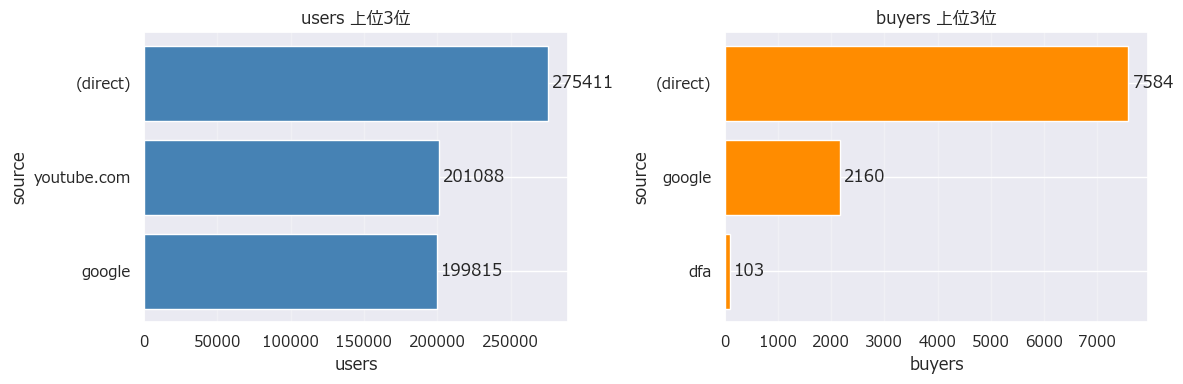

In [5]:
source_summary = (
    df_source.groupby("source", as_index=False)[["users", "buyers"]]
    .sum()
)

source_summary["users"] = pd.to_numeric(source_summary["users"], errors="coerce")
source_summary["buyers"] = pd.to_numeric(source_summary["buyers"], errors="coerce")

top3_users = source_summary.nlargest(3, "users").sort_values("users")
top3_buyers = source_summary.nlargest(3, "buyers").sort_values("buyers")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars_users = axes[0].barh(
    top3_users["source"],
    top3_users["users"],
    color="steelblue"
)
axes[0].bar_label(bars_users, padding=3)
axes[0].set_title("users 上位3位")
axes[0].set_xlabel("users")
axes[0].set_ylabel("source")
axes[0].grid(axis="x", alpha=0.3)

bars_buyers = axes[1].barh(
    top3_buyers["source"],
    top3_buyers["buyers"],
    color="darkorange"
)
axes[1].bar_label(bars_buyers, padding=3)
axes[1].set_title("buyers 上位3位")
axes[1].set_xlabel("buyers")
axes[1].set_ylabel("source")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

ユーザーの使用率が高いsourceの上位3つの割合は91.5%、購入者では96.88%を占めていました。また、どちらも(direct)からの流入が最も多いことが分かりました。

youtube.comを利用したユーザーは二番目に多いにも関わらず、購入者数がとても少ないのはまだ本章だけでは判断できないため、後続の分析で詳細に検証します。

---
### 検証結果

流入元によってユーザー数や購入者数に大きな差が見られたことから、流入元によってユーザー行動や離脱傾向が異なる可能性があるという仮説は一部支持されました。しかし、本章だけでは流入元が離脱にどのような影響を与えているかは判断できないので、次章では、デバイスと組み合わせてどのような利用環境で離脱につながりやすいのかをさらに分析します。

---

## 4.デバイス分析

この章では、流入元ごとに利用されているデバイスの違いを分析します。デバイスによって画面サイズや操作性、利用シーンが異なるため、ユーザー行動や離脱傾向にも違いが生じる可能性があります。この仮説を検証し、離脱ページ分析につながる要因を整理します。

In [6]:
df_device["deviceCategory"].unique()

array(['desktop', 'mobile', 'tablet'], dtype=object)

In [7]:
device_summary = (
    df_device.groupby("deviceCategory", as_index=False)
      .agg(
          users=("users", "sum"),
          buyers=("buyers", "sum")
      )
)

device_summary["cv_rate"] = (
    device_summary["buyers"] / device_summary["users"] * 100
).round(2)

device_summary.sort_values("users", ascending=False)

,deviceCategory,users,buyers,cv_rate
0,desktop,542510,9180,1.69
1,mobile,171441,822,0.48
2,tablet,25160,162,0.64


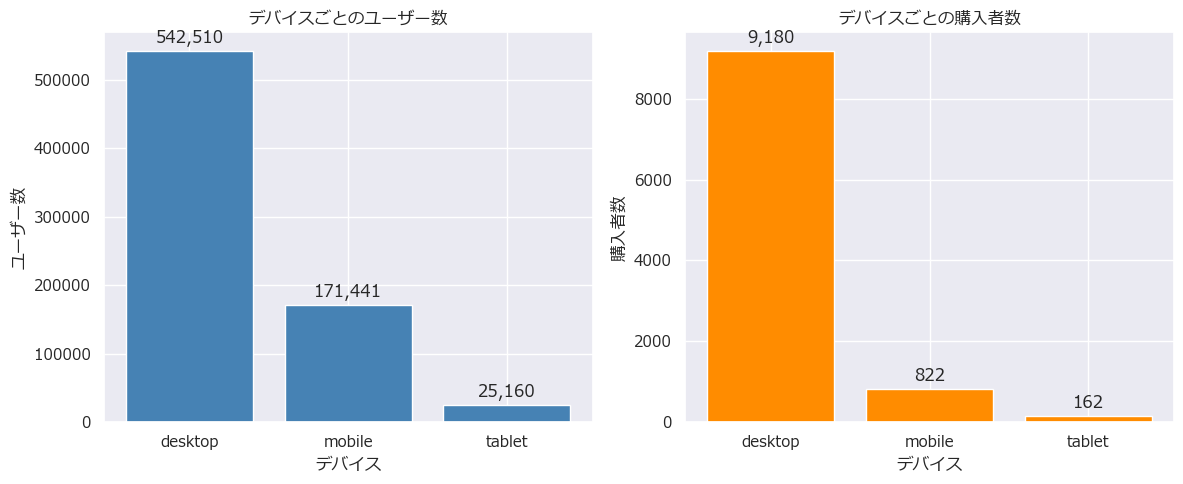

In [8]:
device_summary = (
    df_device.groupby("deviceCategory", as_index=False)
      .agg(
          users=("users", "sum"),
          buyers=("buyers", "sum")
      )
      .sort_values("users", ascending=False)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(
    device_summary["deviceCategory"],
    device_summary["users"],
    color="steelblue"
)
axes[0].bar_label(bars1, fmt="{:,.0f}", padding=3)
axes[0].set_title("デバイスごとのユーザー数")
axes[0].set_xlabel("デバイス")
axes[0].set_ylabel("ユーザー数")

bars2 = axes[1].bar(
    device_summary["deviceCategory"],
    device_summary["buyers"],
    color="darkorange"
)
axes[1].bar_label(bars2, fmt="{:,.0f}", padding=3)
axes[1].set_title("デバイスごとの購入者数")
axes[1].set_xlabel("デバイス")
axes[1].set_ylabel("購入者数")

plt.tight_layout()
plt.show()

カテゴリはdevice、mobile、tabletの3つのみであり、その中でもdesktopの使用率が73%と高いことが分かります。desktopユーザーは大画面で買い物をするので一度にたくさんの商品を見ることができます。一方で、mobileは画面サイズや操作性の制約を受けやすく、ユーザー体験の違いが離脱率に影響していると考えられます。

In [9]:
targets = ["google", "(direct)", "youtube.com", "dfa"]
device_order = ["desktop", "mobile", "tablet"]

source_device_table = (
    df_device[df_device["source"].isin(targets)]
    .groupby(["source", "deviceCategory"], as_index=False)
    .agg(
        users=("users", "sum"),
        buyers=("buyers", "sum")
    )
)

source_device_table["cv_rate"] = (
    source_device_table["buyers"] / source_device_table["users"] * 100
)

source_device_table["source"] = pd.Categorical(
    source_device_table["source"],
    categories=targets,
    ordered=True
)

source_device_table["deviceCategory"] = pd.Categorical(
    source_device_table["deviceCategory"],
    categories=device_order,
    ordered=True
)

source_device_table = source_device_table.sort_values(
    ["source", "deviceCategory"]
)

source_device_table.style.format({
    "users": "{:,.0f}",
    "buyers": "{:,.0f}",
    "cv_rate": "{:.2f}%"
})

,source,deviceCategory,users,buyers,cv_rate
6,google,desktop,"126,819","1,765",1.39%
7,google,mobile,"63,244",330,0.52%
8,google,tablet,"9,752",65,0.67%
0,(direct),desktop,"183,497","7,029",3.83%
1,(direct),mobile,"80,648",465,0.58%
2,(direct),tablet,"11,266",90,0.80%
9,youtube.com,desktop,"182,587",10,0.01%
10,youtube.com,mobile,"15,819",1,0.01%
11,youtube.com,tablet,"2,682",0,0.00%
3,dfa,desktop,"2,723",94,3.45%


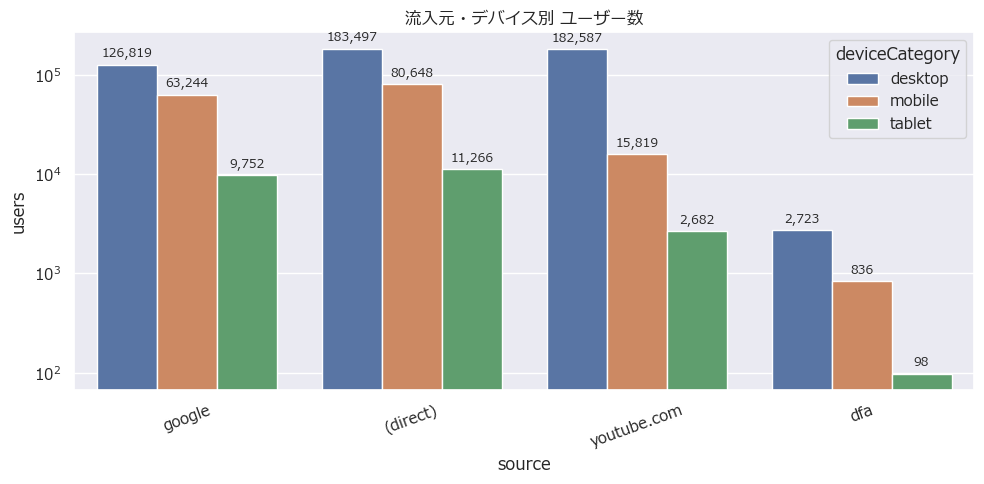

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=source_device_table,
    x="source",
    y="users",
    hue="deviceCategory",
    order=targets,
    hue_order=device_order,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=9)

ax.set_title("流入元・デバイス別 ユーザー数")
ax.set_xlabel("source")
ax.set_ylabel("users")
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

direct、googleはdesktopを使用しているユーザーが半数以上であり、mobileユーザーも比較的多く存在することが分かります。またyoutube.comは基本desktopユーザが大半であることが分かります。それぞれの利用環境に合わせたUI改善や施策を検討する必要があると考えられます。

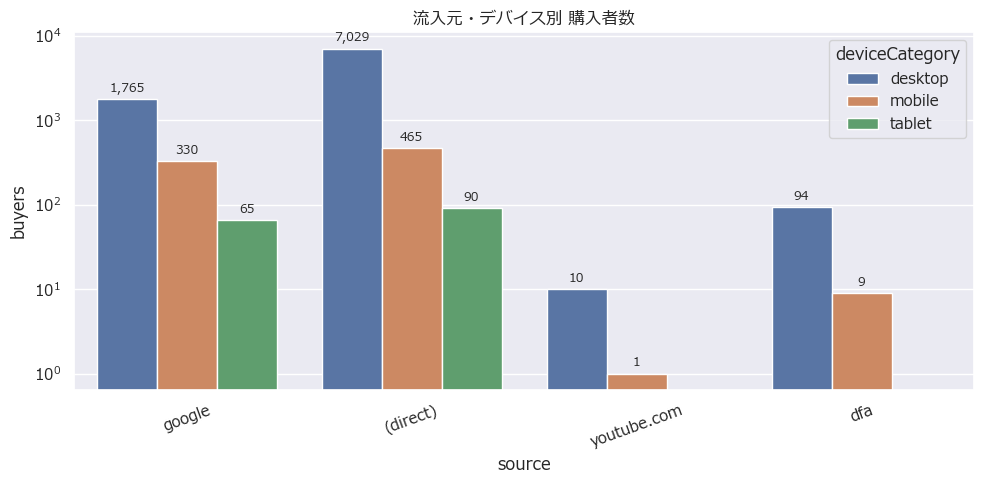

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=source_device_table,
    x="source",
    y="buyers",
    hue="deviceCategory",
    order=targets,
    hue_order=device_order,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=9)

ax.set_title("流入元・デバイス別 購入者数")
ax.set_xlabel("source")
ax.set_ylabel("buyers")
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

direct、googleのdesktopユーザーがよく購入していることが分かります。desktopユーザーの購入までのプロセスは機能しつつあるが、mobileを使用しているユーザーは購入まで結びつきにくい状況に置かれているので、mobile画面のデザインや購入フローに改善点がある可能性があります。

---
### 検証結果
desktop利用者が大半を占めていることが分かり、CV率で見てもdesktopが一番高いのでデバイスの違いによってユーザーの利用環境が異なることが評価されました。この結果にブラウザを紐づけることでさらに離脱ページに至るまでの前提条件を詳細にします。

---

## 5.ブラウザ分析
この章ではよく使用しているブラウザを確認することでユーザーの傾向を確認します。デバイスのように利用環境に左右されないので全ユーザーがどのブラウザを使用しているのかを公平な視点から見ることができます。離脱ページ分析の前提条件の詳細を細かくすることを狙いとして分析します。

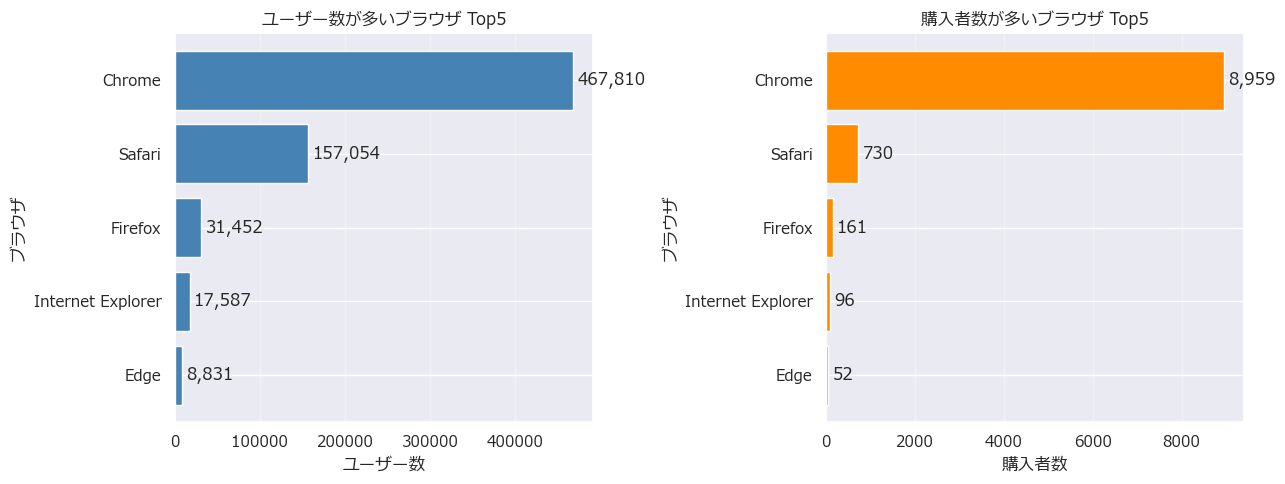

In [12]:
users_top5 = df_browser.nlargest(5, "users").sort_values("users")
buyers_top5 = df_browser.nlargest(5, "buyers").sort_values("buyers")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].barh(
    users_top5["browser"],
    users_top5["users"],
    color="steelblue"
)
axes[0].bar_label(bars1, fmt="{:,.0f}", padding=3)
axes[0].set_title("ユーザー数が多いブラウザ Top5")
axes[0].set_xlabel("ユーザー数")
axes[0].set_ylabel("ブラウザ")
axes[0].grid(axis="x", alpha=0.3)

bars2 = axes[1].barh(
    buyers_top5["browser"],
    buyers_top5["buyers"],
    color="darkorange"
)
axes[1].bar_label(bars2, fmt="{:,.0f}", padding=3)
axes[1].set_title("購入者数が多いブラウザ Top5")
axes[1].set_xlabel("購入者数")
axes[1].set_ylabel("ブラウザ")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Chromeの使用率が70%程でありSafariが20%程度であることが分かります。また購入者ではChromeユーザーが圧倒的であることが分かります。すべてのデバイスに対応しているChromeの割合が高くなっていることが分かります。二つのCV率はChrome:1.91%、Safari:0.46%となっています。SafariユーザーはChromeユーザーに比べて表示崩れが起きている可能性があると考えられます。

## 6.ランディングページ分析
この章では、ユーザーが一番最初にどのページにアクセスをしたのかを確認します。ランディングページと今まで分析してきた前提条件をつなげることで、ユーザーの購入経路がさらに明確になり、次章の離脱ページ分析につなげていきます。

,landing_page,users,buyers,cv_rate
0,/home,518721,6188,1.19
1,/google+redesign/shop+by+brand/youtube,76079,277,0.36
2,/google+redesign/apparel/men++s/men++s+t+shirts,19176,240,1.25
3,/google+redesign/apparel/mens/mens+t+shirts,11763,119,1.01
4,/signin.html,10648,193,1.81
5,/google+redesign/drinkware,8163,89,1.09
6,/basket.html,7915,889,11.23
7,/google+redesign/bags,7721,48,0.62
8,/google+redesign/apparel/men++s/men++s+outerwear,5907,52,0.88
9,/google+redesign/apparel,5745,87,1.51


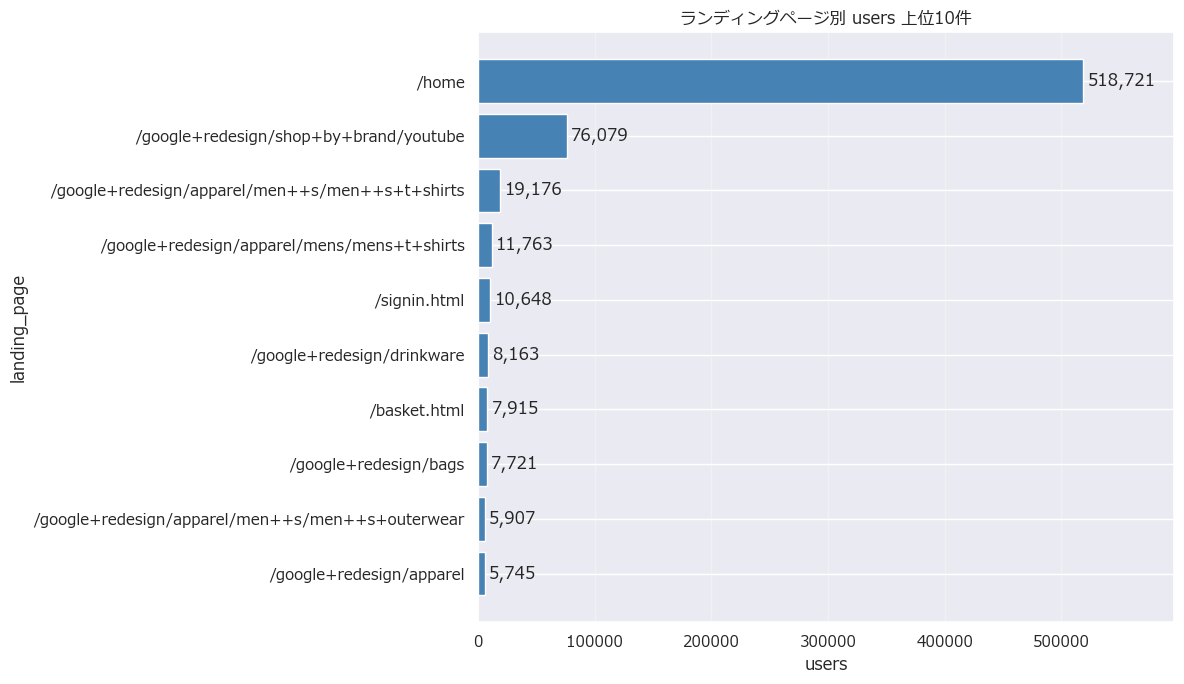

In [13]:
top10_users = (
    df_pagepath.sort_values("users", ascending=False)
      .head(10)
      .sort_values("users", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top10_users["landing_page"],
    top10_users["users"],
    color="steelblue"
)

ax.bar_label(
    bars,
    labels=[f"{v:,.0f}" for v in top10_users["users"]],
    padding=3
)
display(top10_users.sort_values("users", ascending=False))

ax.set_title("ランディングページ別 users 上位10件")
ax.set_xlabel("users")
ax.set_ylabel("landing_page")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, top10_users["users"].max() * 1.15)

plt.tight_layout()
plt.show()

homeを最初に閲覧するユーザーが大半であることが分かります。また、youtubeブランドや、メンズシャツの特定のカテゴリの商品を目的に覗いているユーザーも、多く見られます。homeから入ることはブックマークに登録しているまたは、買うものが決まっていないため、とりあえずホームから探すなど、目的が決まっていないことが考えられます。

In [14]:
target_sources = ["(direct)", "google", "youtube.com"]

home_df = df_pagepath_source[df_pagepath_source["landing_page"] == "/home"].copy()

plot_df = (
    home_df[home_df["source"].isin(target_sources)]
    .groupby("source", as_index=False)
    .agg(
        users=("users", "sum"),
        buyers=("buyers", "sum")
    )
)

plot_df["cv_rate"] = plot_df["buyers"] / plot_df["users"] * 100

plot_df["source_label"] = plot_df["source"].replace({
    "(direct)": "direct",
    "google": "google",
    "youtube.com": "youtube"
})

plot_df["ユーザー構成比"] = plot_df["users"] / home_df["users"].sum() * 100
plot_df["購入者構成比"] = plot_df["buyers"] / home_df["buyers"].sum() * 100

plot_df

,source,users,buyers,cv_rate,source_label,ユーザー構成比,購入者構成比
0,(direct),180400,4788,2.654102,direct,33.929163,76.693897
1,google,116076,1235,1.063958,google,21.831272,19.782156
2,youtube.com,189129,7,0.003701,youtube,35.570890,0.112126


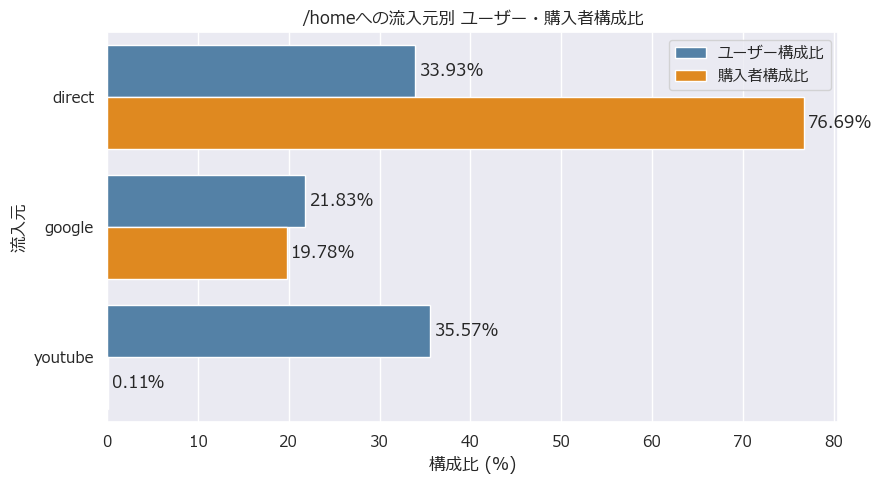

In [15]:
plot_long = plot_df.melt(
    id_vars="source_label",
    value_vars=["ユーザー構成比", "購入者構成比"],
    var_name="指標",
    value_name="構成比"
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=plot_long,
    y="source_label",
    x="構成比",
    hue="指標",
    palette=["steelblue", "darkorange"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title("/homeへの流入元別 ユーザー・購入者構成比")
plt.xlabel("構成比 (%)")
plt.ylabel("流入元")
plt.legend(title="")
plt.tight_layout()
plt.show()

homeの中でも流入元別で見るとある程度均等に分布されていることが分かります。その中で、directでhomeにいくユーザーは実際に購入している割合が高く、購入までの流れに結びつけるためには、youtubeから入るユーザーをdirectに育成する必要があると考えられます。

youtubeからくるユーザーの購入数がこれほど少ないのは、youtubeで気になった商品がhomeのページでは確認できないことが原因で買い物をあきらめてしまうと考えられます。

---
## 7.前提条件のまとめ
本分析では、離脱ページの要因を明らかにするため、流入元・デバイス・ブラウザ・ランディングページの4つの観点から分析を行いました。その中で得られた情報をまとめます。
- youtube.comは利用者は多いがcv率は低い。
- desktop利用者が多く購入者もdesktopユーザーが中心
- mobileの中でsafariを利用しているユーザーのCV率が低いことから、表示画面の改善が必要な可能性がある。
- Chrome利用者が多く、ブラウザによってCV率に差が見られる
- ランディングページではhomeの流入はっもっとも多く、youtube経由のユーザーは購入に繋がりにくい
- youtubeを経由するユーザーは広告などで興味をもった商品までたどり着くまでに離脱をしている可能性があるため、素早く目的の商品を閲覧できるような導線設計をすることが必要になってくる可能性がある。

以上の情報を考えながら次章では離脱ページ分析を行い、施策提案をするための情報をまとめます。



---

## 8.離脱ページ分析
この章では、本分析の大きな仮説「離脱ページがCV率低下の主要な要因の一つである」を今まで分析した前提条件と紐づけて検証していきます。離脱しているポイントを明確にし考えられるユーザーの心理、行動を予測し、施策提案に結びつけます。

In [16]:
df_exit_source = pd.read_csv("離脱ページ×流入元.csv")

target_sources = ["(direct)", "google", "youtube.com"]

exit_source_summary = (
    df_exit_source[df_exit_source["source"].isin(target_sources)]
    .groupby("source", as_index=False)
    .agg(
        pageviews=("pageviews", "sum"),
        exits=("exits", "sum")
    )
)

exit_source_summary["exit_rate"] = (
    exit_source_summary["exits"] / exit_source_summary["pageviews"] * 100
)

exit_source_summary["source_label"] = exit_source_summary["source"].replace({
    "(direct)": "direct",
    "google": "google",
    "youtube.com": "youtube"
})

exit_source_summary = exit_source_summary.set_index("source_label").loc[
    ["direct", "google", "youtube"]
].reset_index()

display(
    exit_source_summary.style.format({
        "pageviews": "{:,.0f}",
        "exits": "{:,.0f}",
        "exit_rate": "{:.2f}%"
    })
)

,source_label,source,pageviews,exits,exit_rate
0,direct,(direct),"1,834,817","368,762",20.10%
1,google,google,"985,032","237,300",24.09%
2,youtube,youtube.com,"349,115","211,151",60.48%


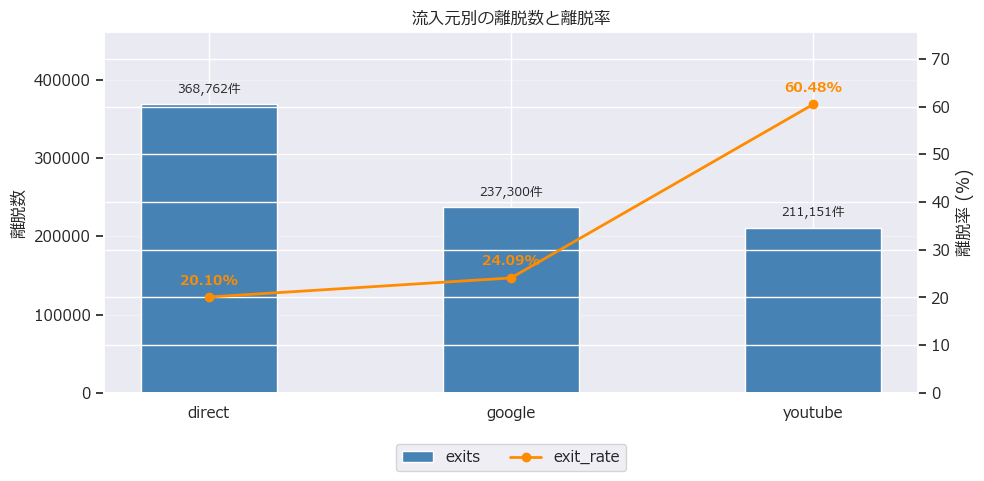

In [17]:
x = np.arange(len(exit_source_summary))

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(
    x,
    exit_source_summary["exits"],
    color="steelblue",
    width=0.45,
    label="exits"
)

ax1.bar_label(
    bars,
    labels=[f'{v:,.0f}件' for v in exit_source_summary["exits"]],
    padding=6,
    fontsize=9
)

ax1.set_ylabel("離脱数")
ax1.set_xticks(x)
ax1.set_xticklabels(exit_source_summary["source_label"])
ax1.grid(axis="y", alpha=0.3)

ax1.set_ylim(0, exit_source_summary["exits"].max() * 1.25)


ax2 = ax1.twinx()

ax2.plot(
    x,
    exit_source_summary["exit_rate"],
    color="darkorange",
    marker="o",
    linewidth=2,
    label="exit_rate"
)

for i, rate in enumerate(exit_source_summary["exit_rate"]):
    ax2.text(
        i,
        rate + 2,
        f"{rate:.2f}%",
        ha="center",
        va="bottom",
        color="darkorange",
        fontsize=10,
        fontweight="bold"
    )

ax2.set_ylabel("離脱率 (%)")
ax2.set_ylim(0, exit_source_summary["exit_rate"].max() * 1.25)

ax1.set_title("流入元別の離脱数と離脱率")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

plt.tight_layout()
plt.show()

利用者の多い流入元の中で離脱とのつながりを調べました。directとgoogleの離脱率は20%前半と、比較的低いが、youtube.comは60%を占めていることが分かります。Youtubeは利用者も多いことから60%ものユーザーを手放しているとなると大きな損失につながる可能性があります。また、youtubeで気になった商品のURLを直接見ることができれば、商品まですぐにたどり着くことができ、CV率向上が期待できます。

In [18]:
targets = {
    "/home": "/home",
    "youtube": "/google+redesign/shop+by+brand/youtube",
    "men's T-shirts": "/google+redesign/apparel/men++s/men++s+t+shirts"
}

df_exit_pagepath["sessions"] = pd.to_numeric(df_exit_pagepath["sessions"], errors="coerce")

summary_list = []

for label, landing in targets.items():
    target_df = df_exit_pagepath[df_exit_pagepath["landing_page"] == landing].copy()
    
    total_sessions = target_df["sessions"].sum()
    
    same_page_exit = target_df.loc[
        target_df["exit_page"] == landing,
        "sessions"
    ].sum()
    
    other_page_exit = total_sessions - same_page_exit
    
    summary_list.append({
        "landing_page": label,
        "状態": "入口ページと同じページで離脱",
        "sessions": same_page_exit,
        "割合": same_page_exit / total_sessions * 100
    })
    
    summary_list.append({
        "landing_page": label,
        "状態": "他ページで離脱",
        "sessions": other_page_exit,
        "割合": other_page_exit / total_sessions * 100
    })

landing_summary = pd.DataFrame(summary_list)

display(
    landing_summary.style.format({
        "sessions": "{:,.0f}",
        "割合": "{:.2f}%"
    })
)

,landing_page,状態,sessions,割合
0,/home,入口ページと同じページで離脱,"406,096",65.92%
1,/home,他ページで離脱,"209,924",34.08%
2,youtube,入口ページと同じページで離脱,"53,675",65.82%
3,youtube,他ページで離脱,"27,871",34.18%
4,men's T-shirts,入口ページと同じページで離脱,"10,639",51.41%
5,men's T-shirts,他ページで離脱,"10,057",48.59%


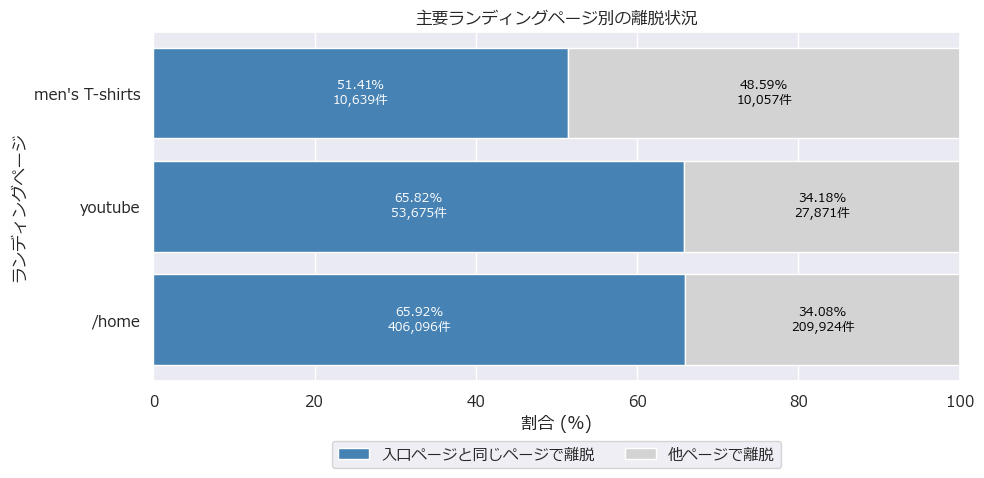

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {
    "入口ページと同じページで離脱": "steelblue",
    "他ページで離脱": "lightgray"
}

left_values = {label: 0 for label in targets.keys()}

for status in ["入口ページと同じページで離脱", "他ページで離脱"]:
    plot_df = landing_summary[landing_summary["状態"] == status]
    
    bars = ax.barh(
        plot_df["landing_page"],
        plot_df["割合"],
        left=[left_values[label] for label in plot_df["landing_page"]],
        color=colors[status],
        label=status
    )
    
    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() / 2,
            f'{row["割合"]:.2f}%\n{row["sessions"]:,.0f}件',
            ha="center",
            va="center",
            fontsize=9,
            color="white" if status == "入口ページと同じページで離脱" else "black"
        )
        
        left_values[row["landing_page"]] += row["割合"]

ax.set_xlim(0, 100)
ax.set_xlabel("割合 (%)")
ax.set_ylabel("ランディングページ")
ax.set_title("主要ランディングページ別の離脱状況")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

よくランディングページとして閲覧されてるページが半分の割合でそのページで離脱していることが分かります。home、youtubeはユーザーが特に多いので改善が必要だと考えます。men's T-shirtsのユーザーは二つほど多くはないが、カテゴリ別で見たときにapparelというくくりで一番多く閲覧されているため、この商品カテゴリのCV率を上げることは今後必要になってくると考えます。

,category,users,buyers,cv_rate
1,apparel,"66,947","1,212",1.81%
4,electronics,"15,734",74,0.47%
2,bags,"14,141",141,1.00%
3,drinkware,"10,860",147,1.35%
9,office,"7,420",134,1.81%


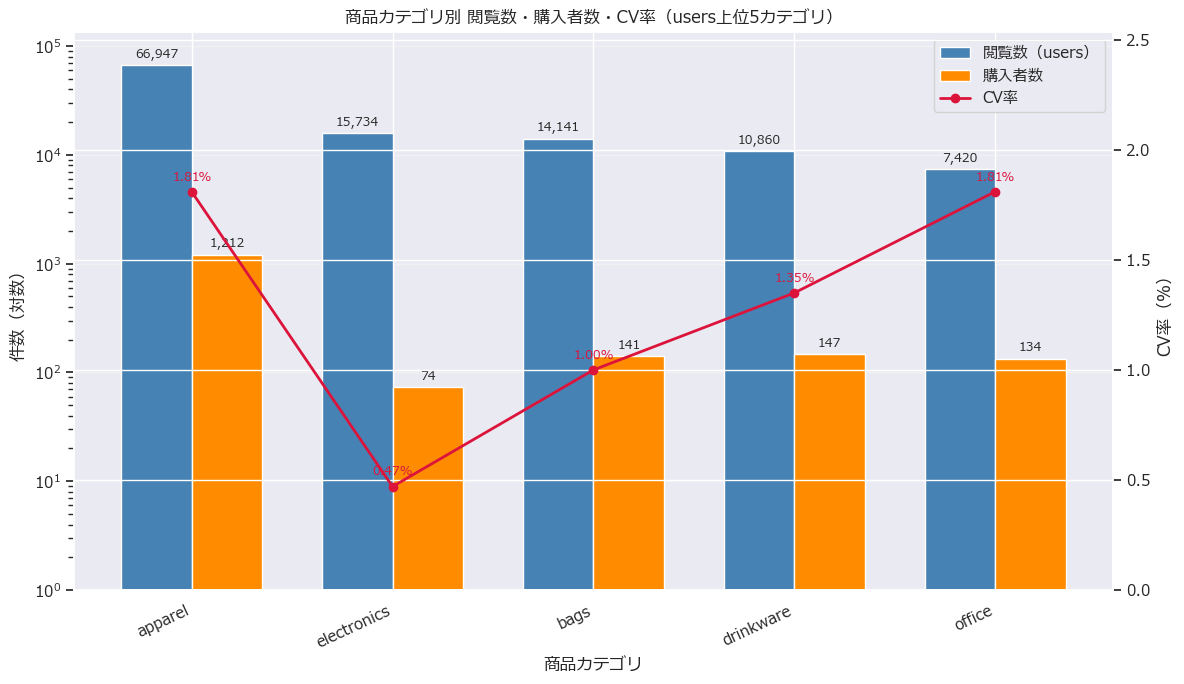

In [20]:
# 商品カテゴリごとの閲覧数・購入者数・CV率（top5）
def extract_product_category(path):
    path = str(path).lower().replace("%20", " ").replace("+", " ")
    prefix = "/google redesign/"

    if not path.startswith(prefix):
        return None

    category = path[len(prefix):].split("/")[0].strip()

    # ブランド導線は商品カテゴリではないため除外
    excluded_categories = {"shop by brand", "brands"}
    if category in excluded_categories:
        return None

    category_map = {
        "electronic": "electronics",
    }

    return category_map.get(category, category)


category_df = df_pagepath.copy()
category_df["category"] = category_df["landing_page"].apply(extract_product_category)
category_df = category_df.dropna(subset=["category"])

category_summary = (
    category_df.groupby("category", as_index=False)
      .agg(
          users=("users", "sum"),
          buyers=("buyers", "sum")
      )
)

category_summary["cv_rate"] = (
    category_summary["buyers"]
    / category_summary["users"]
    * 100
).round(2)

top5_category = (
    category_summary.sort_values("users", ascending=False)
      .head(5)
      .copy()
)

display(
    top5_category.style.format({
        "users": "{:,.0f}",
        "buyers": "{:,.0f}",
        "cv_rate": "{:.2f}%"
    })
)

fig, ax1 = plt.subplots(figsize=(12, 7))

x = list(range(len(top5_category)))
width = 0.35

bars_users = ax1.bar(
    [i - width / 2 for i in x],
    top5_category["users"],
    width=width,
    label="閲覧数（users）",
    color="steelblue"
)

bars_buyers = ax1.bar(
    [i + width / 2 for i in x],
    top5_category["buyers"],
    width=width,
    label="購入者数",
    color="darkorange"
)

ax1.bar_label(
    bars_users,
    labels=[f"{v:,.0f}" for v in top5_category["users"]],
    padding=3,
    fontsize=9
)
ax1.bar_label(
    bars_buyers,
    labels=[f"{v:,.0f}" for v in top5_category["buyers"]],
    padding=3,
    fontsize=9
)

ax1.set_yscale("log")
ax1.set_ylim(1, top5_category["users"].max() * 2)
ax1.set_xticks(x)
ax1.set_xticklabels(top5_category["category"], rotation=25, ha="right")
ax1.set_xlabel("商品カテゴリ")
ax1.set_ylabel("件数（対数）")
ax1.set_title("商品カテゴリ別 閲覧数・購入者数・CV率（users上位5カテゴリ）")
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    x,
    top5_category["cv_rate"],
    color="crimson",
    marker="o",
    linewidth=2,
    label="CV率"
)

for i, cv_rate in enumerate(top5_category["cv_rate"]):
    ax2.annotate(
        f"{cv_rate:.2f}%",
        (i, cv_rate),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        color="crimson",
        fontsize=9
    )

ax2.set_ylabel("CV率（%）")
ax2.set_ylim(0, max(top5_category["cv_rate"].max() * 1.4, 2.5))

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()


先ほど、apparelなどの商品カテゴリについて分析したため、商品カテゴリについて考えます。ユーザー数の多い商品カテゴリは以上のような結果になりました。apparelの購入数が1212件とほかの商品と比べて多いことが分かりました。CV率を上げるためには、ユーザーの求めてる商品を提供できるかがカギになってくると思うので、商品の種類を増やすことが必要になると考えます。

## 9.施策提案
これまでの分析を踏まえてcv率を上げるための施策を紹介します。

### 施策①：homeページ・youtubeページのUIデザイン変更
- ターゲット：ランディングページがhomeもしくはyoutubeのユーザー
- 目的：ランディングページでの離脱減少
- 内容：homeでは商品カテゴリを一覧でだし、興味の惹かれるカテゴリにアクセスしやすくする。youtubeでは紹介してる商品に直接移動できるリンクを張り付けるとともに、その商品と類似した商品または、付属であると便利な商品を1画面で見れるようにする。

### 施策②：ログイン画面・ユーザー登録の簡略化
- ターゲット：全ユーザー
- 目的：購入導線の短縮
- 内容：アカウントを作成する時間を短くし、簡単に商品ページに飛ぶことでストレスフリーで買い物をすることができる。氏名、メールアドレスは入力し、カード番号はパソコンに保存されている場合はそれを自動で持ってくる。(ない場合は入力)




## 今後の展望
本分析では、ユーザー行動を分析し、CV率向上に向けた改善施策を提案しました。

今後は、提案した施策についてA/Bテストを実施し、施策実施前後のCV率や離脱率の変化を比較することで、改善効果を検証したいと思います。

また、検証結果を踏まえて施策を改善し、継続的にユーザー体験を向上させるサイクルを構築したいと思います。